# Pairwise SWD between real and random datasets

Drop-in replacement for `w2_random_data.ipynb`: uses `ot.sliced_wasserstein_distance` instead of the Frechet/Bures W2.

Same dataset structure (Wang H-CDR3, iReceptor, Random aa, Random shuffled, Random) and same plot layout. SWD does not assume Gaussianity, so this serves as a robustness check that real datasets remain clearly separable from randomized controls regardless of distributional shape.

In [1]:
!pip install -q pot

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import pandas as pd
import torch
import ot
from collections import Counter

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device,
      '|', torch.cuda.get_device_name(1) if torch.cuda.is_available() else '')

Using device: cuda | Tesla V100-PCIE-32GB


In [2]:
!nvidia-smi

Mon May 11 13:19:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.51.03              Driver Version: 575.51.03      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-PCIE-32GB           Off |   00000000:01:00.0 Off |                    0 |
| N/A   32C    P0             36W /  250W |   31430MiB /  32768MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
def get_swd(act1, act2, n_projections=500, p=2, seed=0):
    """Sliced Wasserstein Distance between two embedding sets.

    Drop-in replacement for `get_w2`. Returns SWD^p so the scale is comparable
    to the squared (FID-style) W2 used previously.

    Runs on GPU automatically if available (POT 0.9+ uses torch backend when
    given torch tensors). float32 is used to halve memory/FLOPs vs float64.

    Args:
        act1, act2: arrays / tensors of shape (n_samples, n_features).
        n_projections: number of random 1D projections. 500 is a starting point;
                       bump to 2000 for ~1024-d embeddings if variance across
                       runs is too high (CV > 5%).
        p: order of the SWD (p=2 is standard).
        seed: RNG seed for reproducibility.
    """
    a = torch.as_tensor(act1, dtype=torch.float32, device=device)
    b = torch.as_tensor(act2, dtype=torch.float32, device=device)
    val = ot.sliced_wasserstein_distance(
        a, b, n_projections=n_projections, p=p, seed=seed
    )
    return float(val) ** p

In [4]:
def get_pairwise_swd(datasets, n_projections=500, p=2):
    """Pairwise SWD over a list of datasets, same iteration order as get_pairwise_w2.

    Memory-aware: the outer dataset `i` is moved to GPU once and reused across
    the inner loop; `j` is moved per-call and freed after each pair to avoid
    accumulating tensors in PyTorch's caching allocator.
    """
    distance_matrices = []
    n_datasets = len(datasets)
    for i in range(n_datasets):
        a = torch.as_tensor(datasets[i], dtype=torch.float32, device=device)
        for j in range(i, n_datasets):
            if j == i:
                b = a  # diagonal — reuse the same tensor
            else:
                b = torch.as_tensor(datasets[j], dtype=torch.float32, device=device)
            d = get_swd(
                a, b,
                n_projections=n_projections, p=p,
                seed=i * 100 + j,
            )
            distance_matrices.append(d)
            print(f'  ({i}, {j}) -> {d}')
            if j != i:
                del b
                if device == 'cuda':
                    torch.cuda.empty_cache()
        del a
        if device == 'cuda':
            torch.cuda.empty_cache()
    return distance_matrices

In [15]:
from scipy.spatial.distance import squareform
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap, LogNorm

def build_plot(distance_matrices, model):
    colors = ["#023047", "#219EBC", "#8ECAE6"]  # Dark blue to light blue
    cmap = LinearSegmentedColormap.from_list("my_colormap", colors)

    n_datasets = 5
    dataset_size = 300000

    fig, ax = plt.subplots(figsize=(12, 12))

    combined_matrix = np.zeros((n_datasets, n_datasets))
    idx = 0
    for i in range(n_datasets):
        for j in range(i, n_datasets):
            combined_matrix[i, j] = distance_matrices[idx]
            combined_matrix[j, i] = combined_matrix[i, j]
            idx += 1

    sns.heatmap(combined_matrix, cmap=cmap, annot=True, annot_kws={"size": 16}, cbar=False, square=True)

    ax.set_xticklabels(['Wang H-CDR3', 'iReceptor', 'Random aa', 'Random shuffled', 'Random'], fontsize=18, rotation=45)
    ax.set_yticklabels(['Wang H-CDR3', 'iReceptor', 'Random aa', 'Random shuffled', 'Random'], fontsize=18, rotation=45)
    ax.set_title(f"SWD between datasets, {model.upper()}, N = {dataset_size}", fontsize=20)

    plt.tight_layout()
    plt.savefig(f'swd_heatmap_{model}_{dataset_size}')
    plt.show()

In [7]:
n_max = 300000

esm2_df1 = torch.load(f'/doctorai/marinafr/2023/airr_atlas/analysis/output/esm2/freq_test/flanking_res/wang_790000.pt').numpy()[:n_max]
esm2_df2 = torch.load(f'/doctorai/marinafr/2023/airr_atlas/analysis/output/esm2/freq_test/flanking_res/ireceptor_790000.pt').numpy()[:n_max]
esm2_df3 = torch.load(f'/doctorai/marinafr/2023/airr_atlas/analysis/output/esm2/ireceptor/random/random_aa.pt').numpy()[:n_max]
esm2_df4 = torch.load(f'/doctorai/marinafr/2023/airr_atlas/analysis/output/esm2/ireceptor/random/random_shuffled.pt').numpy()[:n_max]
esm2_df5 = torch.load(f'/doctorai/marinafr/2023/airr_atlas/analysis/output/esm2/ireceptor/random/random.pt').numpy()[:n_max]

ab2_df1 = torch.load(f'/doctorai/marinafr/2023/airr_atlas/analysis/output/antiberta2/freq_test/flanking_res/wang_790000.pt').numpy()[:n_max]
ab2_df2 = torch.load(f'/doctorai/marinafr/2023/airr_atlas/analysis/output/antiberta2/freq_test/flanking_res/ireceptor_790000.pt').numpy()[:n_max]
ab2_df3 = torch.load(f'/doctorai/marinafr/2023/airr_atlas/analysis/output/antiberta2/ireceptor/random/random_aa.pt').numpy()[:n_max]
ab2_df4 = torch.load(f'/doctorai/marinafr/2023/airr_atlas/analysis/output/antiberta2/ireceptor/random/random_shuffled.pt').numpy()[:n_max]
ab2_df5 = torch.load(f'/doctorai/marinafr/2023/airr_atlas/analysis/output/antiberta2/ireceptor/random/random.pt').numpy()[:n_max]

ohe_df1 = torch.load(f'/doctorai/evgeniie/AIRR_atlas_2023/data/marina_august/embeddings_ireceptor_ohe/wang_ohe.pt').numpy()[:n_max]
ohe_df2 = torch.load(f'/doctorai/evgeniie/AIRR_atlas_2023/data/marina_august/embeddings_ireceptor_ohe/ireceptor_ohe.pt').numpy()[:n_max]
ohe_df3 = torch.load(f'/doctorai/marinafr/2023/airr_atlas/analysis/output/ohe/ireceptor/random/random_aa.pt').numpy()[:n_max]
ohe_df4 = torch.load(f'/doctorai/marinafr/2023/airr_atlas/analysis/output/ohe/ireceptor/random/random_shuffled.pt').numpy()[:n_max]
ohe_df5 = torch.load(f'/doctorai/marinafr/2023/airr_atlas/analysis/output/ohe/ireceptor/random/random.pt').numpy()[:n_max]


In [8]:
esm2_datasets = [esm2_df1, esm2_df2, esm2_df3, esm2_df4, esm2_df5]
ab2_datasets  = [ab2_df1,  ab2_df2,  ab2_df3,  ab2_df4,  ab2_df5]
ohe_datasets  = [ohe_df1,  ohe_df2,  ohe_df3,  ohe_df4,  ohe_df5]

In [9]:
esm2_distance_matrices = get_pairwise_swd(esm2_datasets)
esm2_distance_matrices

  (0, 0) -> 0.0
  (0, 1) -> 8.217432601583116e-06
  (0, 2) -> 2.7737196316123848e-05
  (0, 3) -> 4.073162604677585e-05
  (0, 4) -> 0.0006827232724611193
  (1, 1) -> 0.0
  (1, 2) -> 3.0868245237465836e-05
  (1, 3) -> 3.3432749332111024e-05
  (1, 4) -> 0.0007816543510860731
  (2, 2) -> 0.0
  (2, 3) -> 4.036874713565287e-05
  (2, 4) -> 0.0005953058944859792
  (3, 3) -> 0.0
  (3, 4) -> 0.0006878271554049444
  (4, 4) -> 0.0


[0.0,
 8.217432601583116e-06,
 2.7737196316123848e-05,
 4.073162604677585e-05,
 0.0006827232724611193,
 0.0,
 3.0868245237465836e-05,
 3.3432749332111024e-05,
 0.0007816543510860731,
 0.0,
 4.036874713565287e-05,
 0.0005953058944859792,
 0.0,
 0.0006878271554049444,
 0.0]

In [10]:
torch.save(torch.tensor(esm2_distance_matrices), f'swd_esm2.pt')

In [11]:
ab2_distance_matrices = get_pairwise_swd(ab2_datasets)
torch.save(torch.tensor(ab2_distance_matrices), f'swd_ab2.pt')

  (0, 0) -> 0.0
  (0, 1) -> 0.0005051372841332093
  (0, 2) -> 0.009046741053902407
  (0, 3) -> 0.025074856457438566
  (0, 4) -> 0.06519176340893384
  (1, 1) -> 0.0
  (1, 2) -> 0.010061287022407106
  (1, 3) -> 0.030703358342955234
  (1, 4) -> 0.062438205265280544
  (2, 2) -> 0.0
  (2, 3) -> 0.00951482167411305
  (2, 4) -> 0.05680206569192792
  (3, 3) -> 0.0
  (3, 4) -> 0.03530651334206514
  (4, 4) -> 0.0


In [12]:
for i, arr in enumerate(ohe_datasets, 1):
    print(i, arr.shape)

1 (300000, 660)
2 (300000, 660)
3 (300000, 660)
4 (300000, 660)
5 (300000, 660)


In [13]:
ohe_distance_matrices = get_pairwise_swd(ohe_datasets)
torch.save(torch.tensor(ohe_distance_matrices), f'swd_ohe.pt')

  (0, 0) -> 0.0
  (0, 1) -> 3.0162467075959968e-05
  (0, 2) -> 3.742451149241059e-05
  (0, 3) -> 0.0020797001702566598
  (0, 4) -> 0.0026677493212712428
  (1, 1) -> 0.0
  (1, 2) -> 7.137305200579215e-06
  (1, 3) -> 0.0022769459864915853
  (1, 4) -> 0.0028631003313309145
  (2, 2) -> 0.0
  (2, 3) -> 0.002116513786744323
  (2, 4) -> 0.002852788189727784
  (3, 3) -> 0.0
  (3, 4) -> 0.0005872671944502951
  (4, 4) -> 0.0


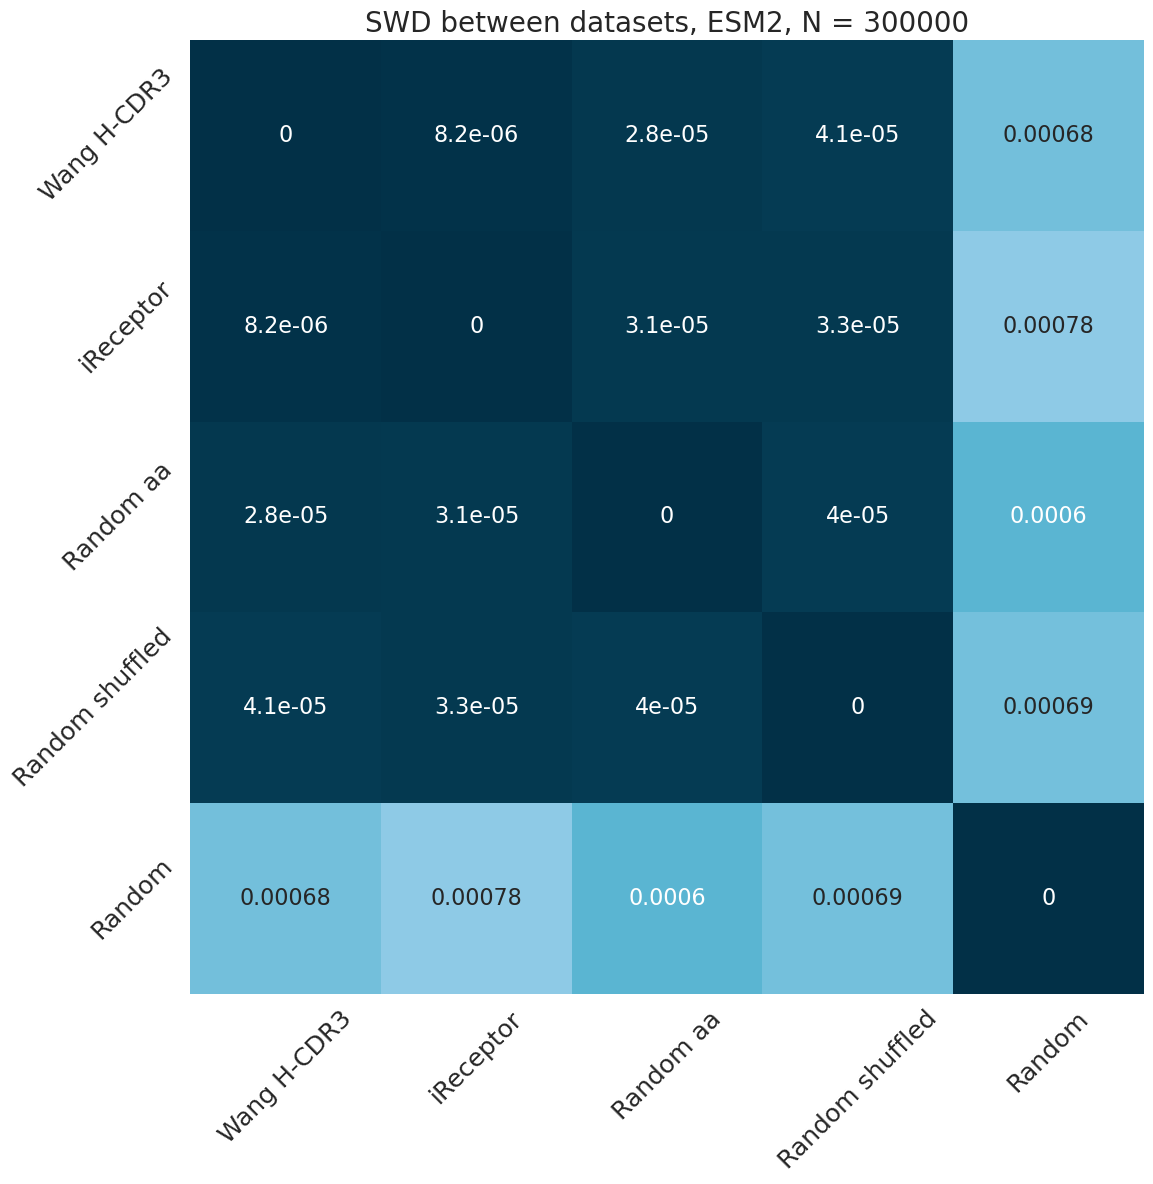

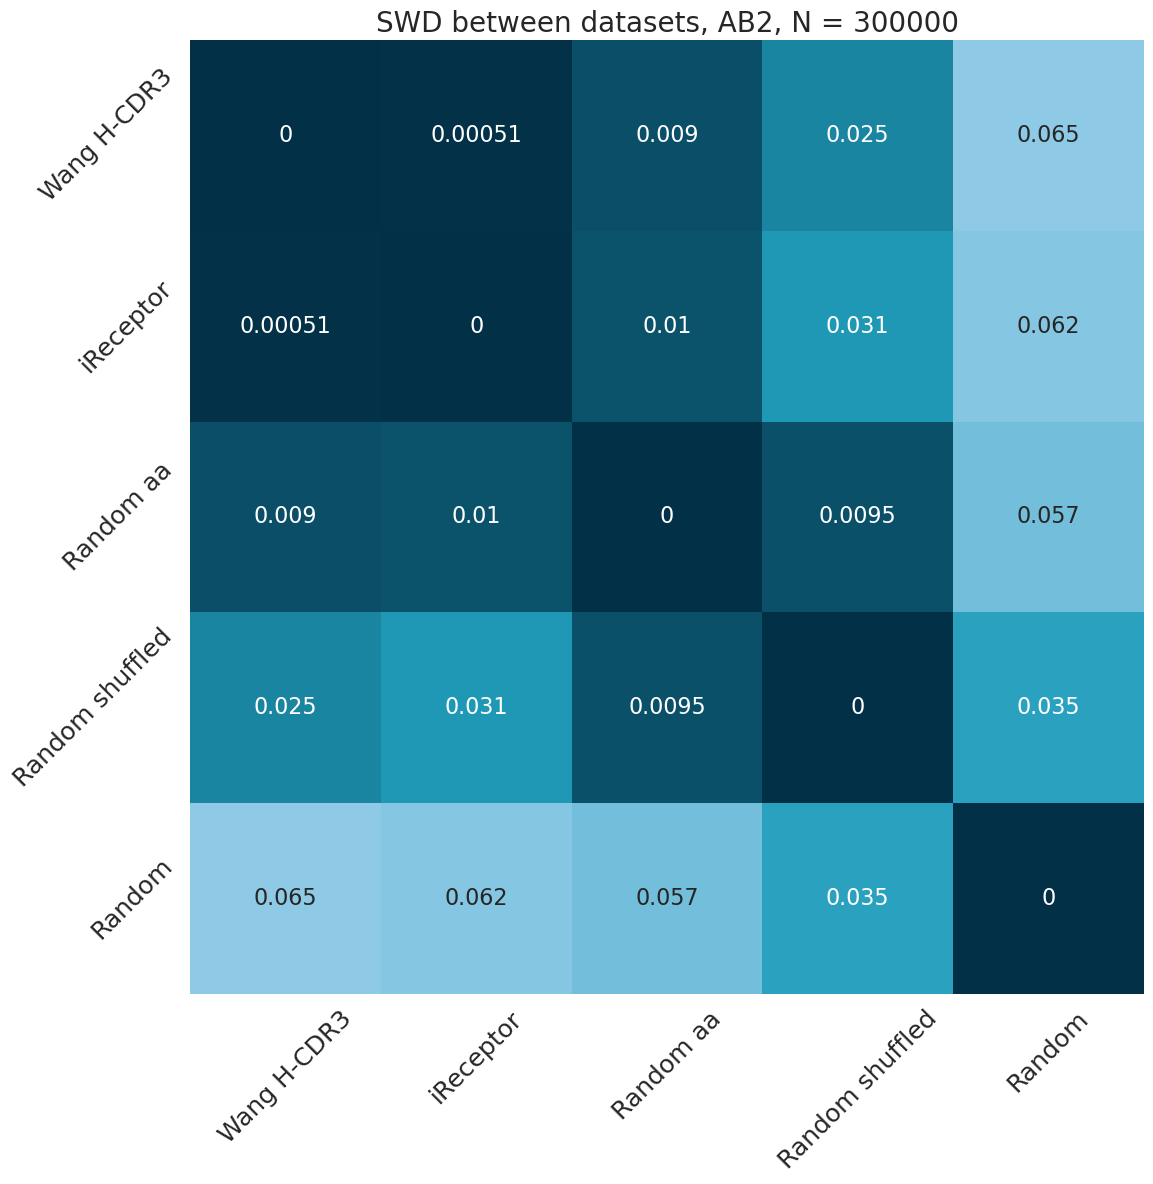

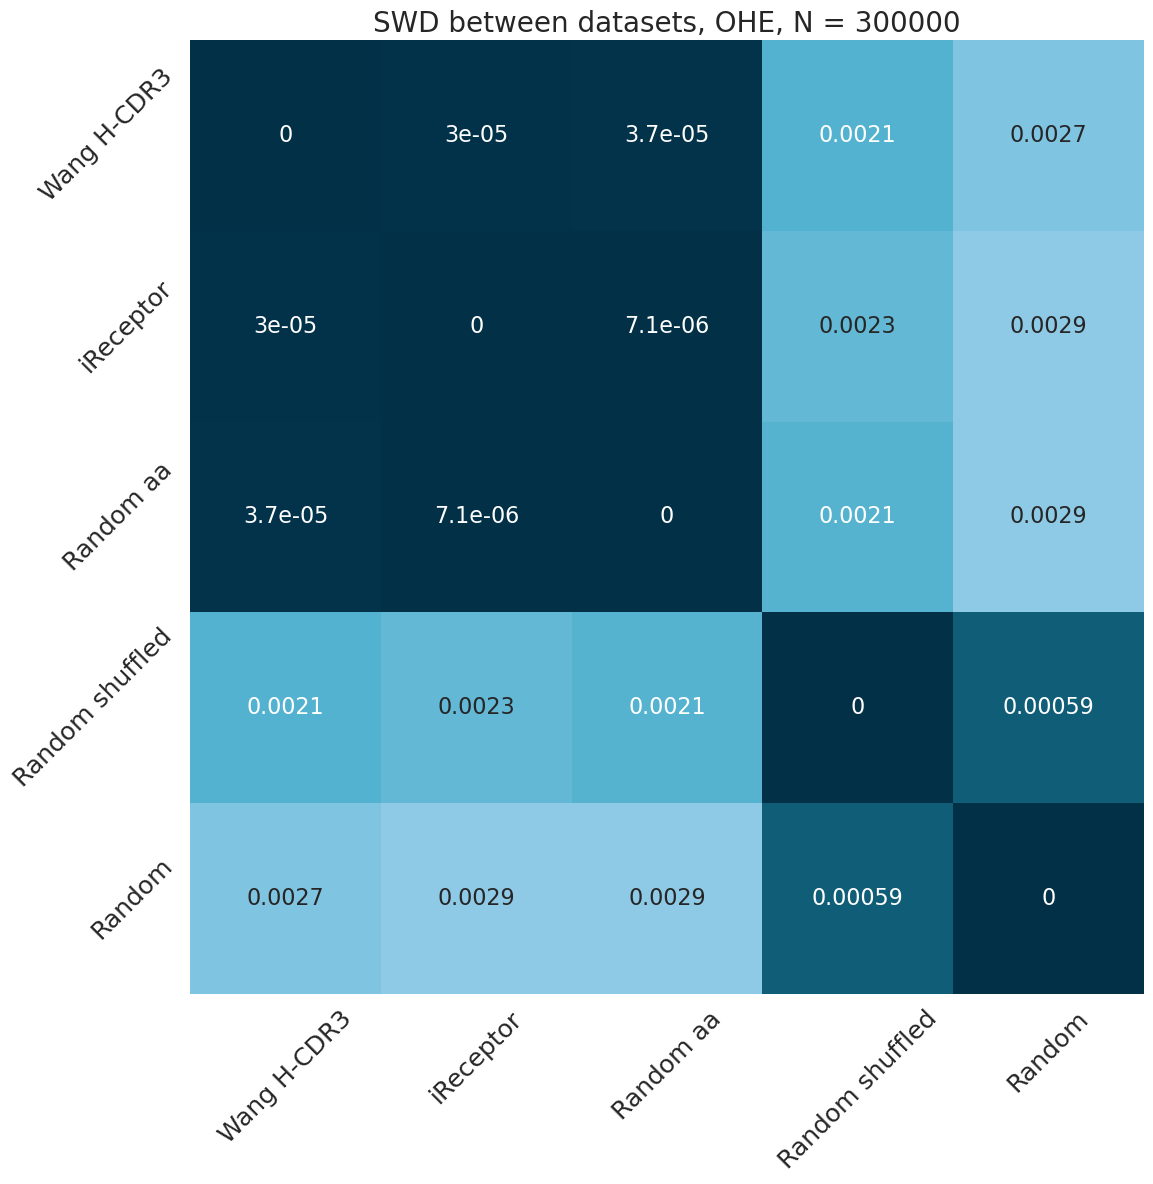

In [16]:
build_plot(esm2_distance_matrices, 'esm2')
build_plot(ab2_distance_matrices,  'ab2')
build_plot(ohe_distance_matrices,  'ohe')

## W2 vs SWD scatter comparison

Quantitative comparison of the W2 (Bures, Gaussian-approximation) and SWD
(assumption-free) pairwise distances computed in this notebook and in
`w2_random_data.ipynb`.

For each encoder (AB2, ESM2, OHE) and each off-diagonal pair of datasets
(Wang, iReceptor, Random_aa, Random_shuffled, Random) we plot one point with
W2 on the x-axis and SWD on the y-axis. If both metrics rank the pairs
identically, the points fall on a monotonic curve and Spearman ρ approaches 1.0.

Self-pairs (i == j) are excluded: they are zero by construction (~1e-13) and
would collapse on the log-log axis.

**Caveat on batch sizes.** SWD here was computed at N = 300,000 per dataset
(see `n_max` above), while W2 in `w2_random_data.ipynb` was computed at
N = 790,000. Spearman ρ is robust to this difference (it depends only on
within-encoder rank order), but the per-encoder Pearson(log) coefficient and
the absolute slope of the SWD-vs-W2 trend should be interpreted with the
batch-size discrepancy in mind. To make absolute values directly comparable,
recompute one of the two at the same N.

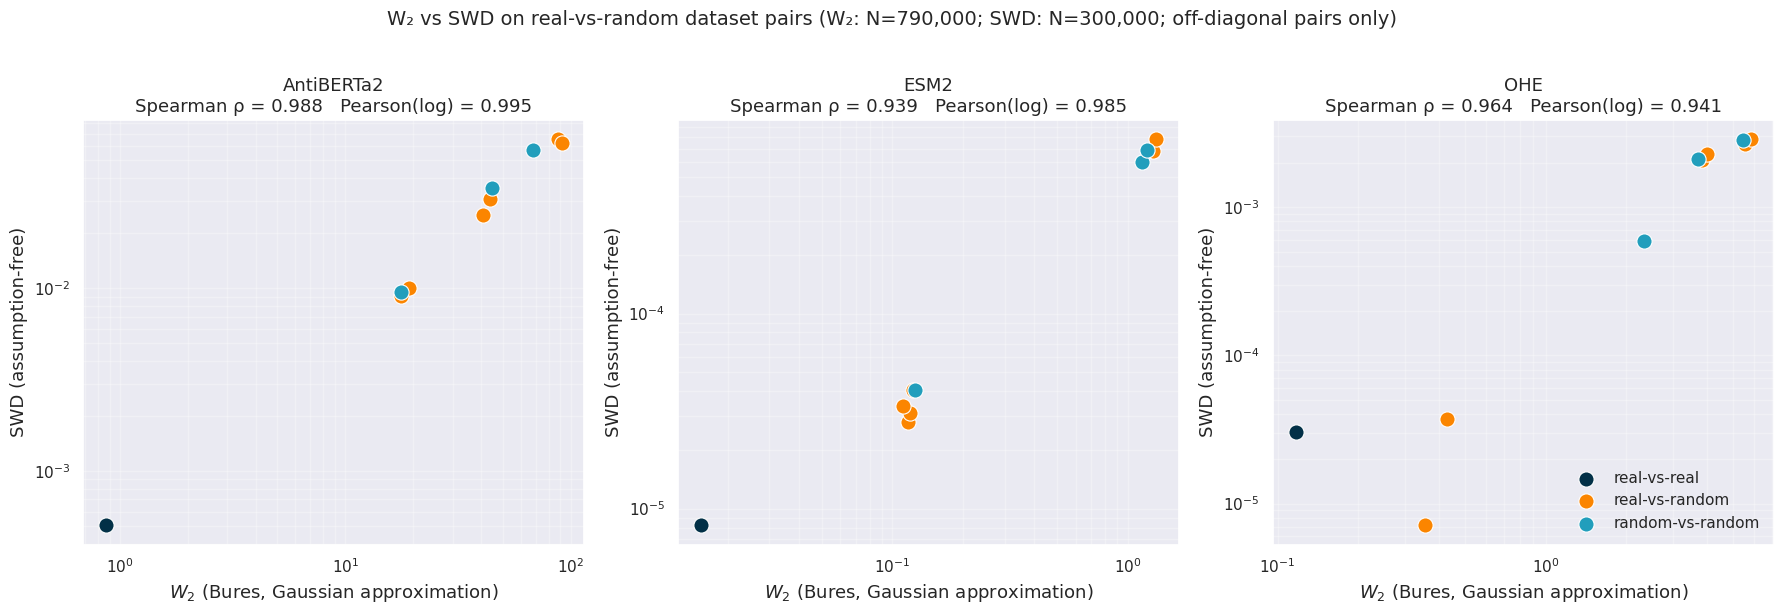

In [12]:
from scipy.stats import spearmanr, pearsonr

# --- Per-encoder pairwise distance vectors ---
# Both notebooks save flattened upper-triangular distance lists in the same
# order (nested loop `for i in range(5): for j in range(i, 5):`), so the
# k-th entry of each file corresponds to the same dataset pair.
encoders = ['ab2', 'esm2', 'ohe']
encoder_labels = ['AntiBERTa2', 'ESM2', 'OHE']

w2  = {e: torch.load(f'./w2_{e}.pt').numpy()  for e in encoders}
swd = {e: torch.load(f'swd_{e}.pt').numpy()   for e in encoders}

# --- Reconstruct pair labels in the same order ---
dataset_names = ['Wang', 'iReceptor', 'Random_aa', 'Random_shuffled', 'Random']
pairs = [(dataset_names[i], dataset_names[j])
         for i in range(5) for j in range(i, 5)]

REAL = {'Wang', 'iReceptor'}


def pair_kind(a, b):
    if a == b:
        return 'self'
    if a in REAL and b in REAL:
        return 'real-vs-real'
    if (a in REAL) ^ (b in REAL):
        return 'real-vs-random'
    return 'random-vs-random'


kinds = np.array([pair_kind(a, b) for a, b in pairs])
off_diag = kinds != 'self'  # ~0 by construction, would collapse on log-log

kind_colors = {
    'real-vs-real':     '#023047',
    'real-vs-random':   '#FB8500',
    'random-vs-random': '#219EBC',
}

# --- Plot: 3 panels (one per encoder), log-log scatter ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, e, label in zip(axes, encoders, encoder_labels):
    w = w2[e][off_diag]
    s = swd[e][off_diag]
    k = kinds[off_diag]

    for kind, color in kind_colors.items():
        sub = k == kind
        ax.scatter(
            w[sub], s[sub], c=color, label=kind,
            s=120, edgecolor='white', linewidth=0.8, zorder=3,
        )

    rho_s, _ = spearmanr(w, s)
    rho_p, _ = pearsonr(np.log(w), np.log(s))

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$W_2$ (Bures, Gaussian approximation)', fontsize=13)
    ax.set_ylabel('SWD (assumption-free)', fontsize=13)
    ax.set_title(
        f'{label}\nSpearman ρ = {rho_s:.3f}   Pearson(log) = {rho_p:.3f}',
        fontsize=13,
    )
    ax.grid(alpha=0.3, which='both')

axes[-1].legend(loc='lower right', frameon=False, fontsize=11)

fig.suptitle(
    'W₂ vs SWD on real-vs-random dataset pairs '
    '(W₂: N=790,000; SWD: N=300,000; off-diagonal pairs only)',
    fontsize=14, y=1.02,
)

plt.tight_layout()
plt.savefig('w2_vs_swd_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

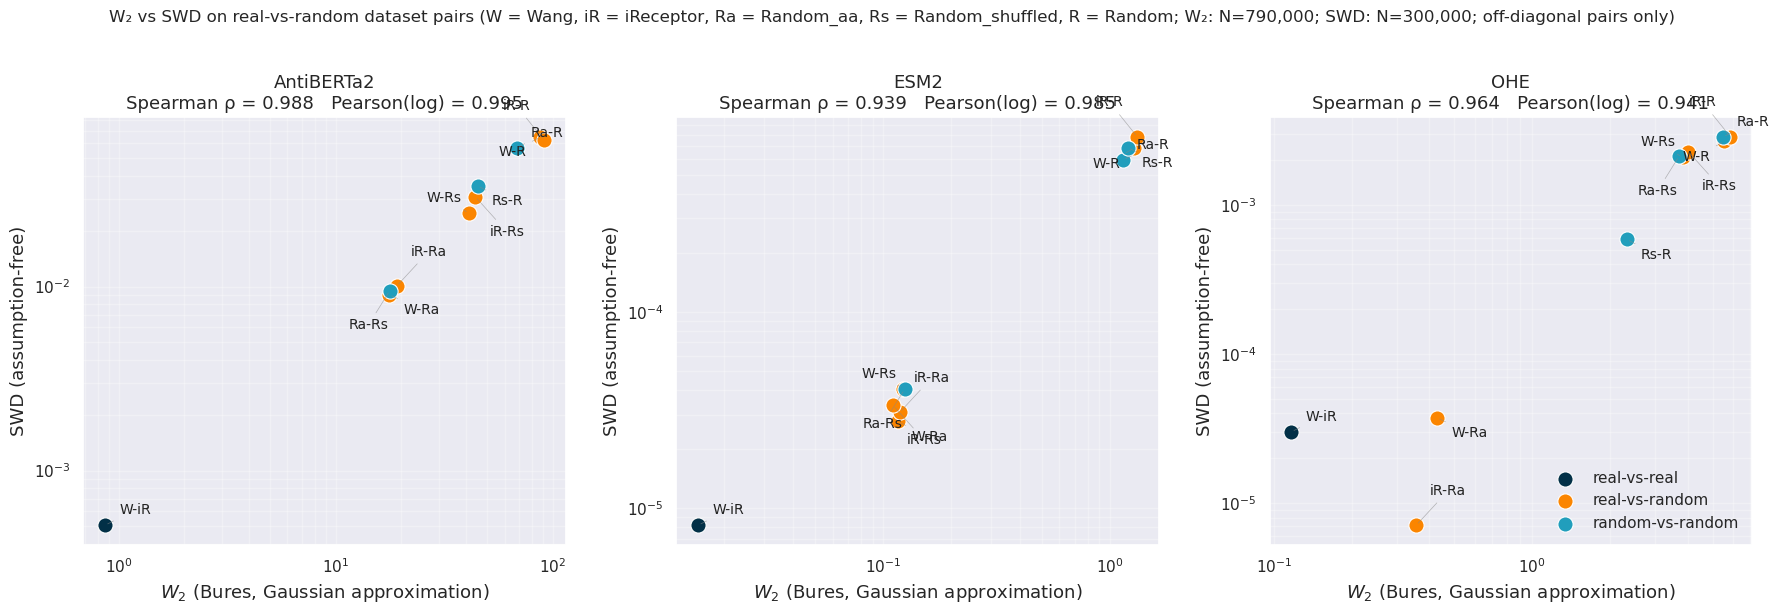

In [13]:
from scipy.stats import spearmanr, pearsonr

# --- Per-encoder pairwise distance vectors ---
# Both notebooks save flattened upper-triangular distance lists in the same
# order (nested loop `for i in range(5): for j in range(i, 5):`), so the
# k-th entry of each file corresponds to the same dataset pair.
encoders = ['ab2', 'esm2', 'ohe']
encoder_labels = ['AntiBERTa2', 'ESM2', 'OHE']

w2  = {e: torch.load(f'./w2_{e}.pt').numpy()  for e in encoders}
swd = {e: torch.load(f'swd_{e}.pt').numpy()   for e in encoders}

# --- Reconstruct pair labels in the same order ---
dataset_names = ['Wang', 'iReceptor', 'Random_aa', 'Random_shuffled', 'Random']
short_names   = ['W',    'iR',        'Ra',        'Rs',              'R']
pairs       = [(dataset_names[i], dataset_names[j])
               for i in range(5) for j in range(i, 5)]
short_pairs = [f'{short_names[i]}-{short_names[j]}'
               for i in range(5) for j in range(i, 5)]

REAL = {'Wang', 'iReceptor'}


def pair_kind(a, b):
    if a == b:
        return 'self'
    if a in REAL and b in REAL:
        return 'real-vs-real'
    if (a in REAL) ^ (b in REAL):
        return 'real-vs-random'
    return 'random-vs-random'


kinds       = np.array([pair_kind(a, b) for a, b in pairs])
short_pairs = np.array(short_pairs)
off_diag    = kinds != 'self'  # ~0 by construction, would collapse on log-log

kind_colors = {
    'real-vs-real':     '#023047',
    'real-vs-random':   '#FB8500',
    'random-vs-random': '#219EBC',
}

# Cyclic label offsets (in pixels). 8 directions ensure that overlapping
# clusters get spread out without any label running far from its point.
LABEL_OFFSETS = [
    ( 10,   8),  # upper right
    ( 10, -14),  # lower right
    (-30,   8),  # upper left
    (-30, -14),  # lower left
    ( 10,  22),  # far upper right
    ( 10, -28),  # far lower right
    (-30,  22),  # far upper left
    (-30, -28),  # far lower left
]

# --- Plot: 3 panels (one per encoder), log-log scatter ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, e, label in zip(axes, encoders, encoder_labels):
    w  = w2[e][off_diag]
    s  = swd[e][off_diag]
    k  = kinds[off_diag]
    sp = short_pairs[off_diag]

    for kind, color in kind_colors.items():
        sub = k == kind
        ax.scatter(
            w[sub], s[sub], c=color, label=kind,
            s=120, edgecolor='white', linewidth=0.8, zorder=3,
        )

    # Place labels at fixed pixel offsets, cycling through 8 directions.
    # Bounded by construction, so the figure cannot blow up at savefig.
    for idx, (xi, yi, name) in enumerate(zip(w, s, sp)):
        dx, dy = LABEL_OFFSETS[idx % len(LABEL_OFFSETS)]
        ax.annotate(
            name,
            xy=(xi, yi),
            xytext=(dx, dy),
            textcoords='offset points',
            fontsize=10,
            color='#222',
            zorder=4,
            arrowprops=dict(arrowstyle='-', color='#888', lw=0.5, alpha=0.6),
        )

    rho_s, _ = spearmanr(w, s)
    rho_p, _ = pearsonr(np.log(w), np.log(s))

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$W_2$ (Bures, Gaussian approximation)', fontsize=13)
    ax.set_ylabel('SWD (assumption-free)', fontsize=13)
    ax.set_title(
        f'{label}\nSpearman ρ = {rho_s:.3f}   Pearson(log) = {rho_p:.3f}',
        fontsize=13,
    )
    ax.grid(alpha=0.3, which='both')

axes[-1].legend(loc='lower right', frameon=False, fontsize=11)

# Short-name legend in the figure-level title for reference.
fig.suptitle(
    'W₂ vs SWD on real-vs-random dataset pairs '
    '(W = Wang, iR = iReceptor, Ra = Random_aa, Rs = Random_shuffled, R = Random; '
    'W₂: N=790,000; SWD: N=300,000; off-diagonal pairs only)',
    fontsize=12, y=1.02,
)

plt.tight_layout()
plt.savefig('w2_vs_swd_scatter.png', dpi=300)
plt.show()


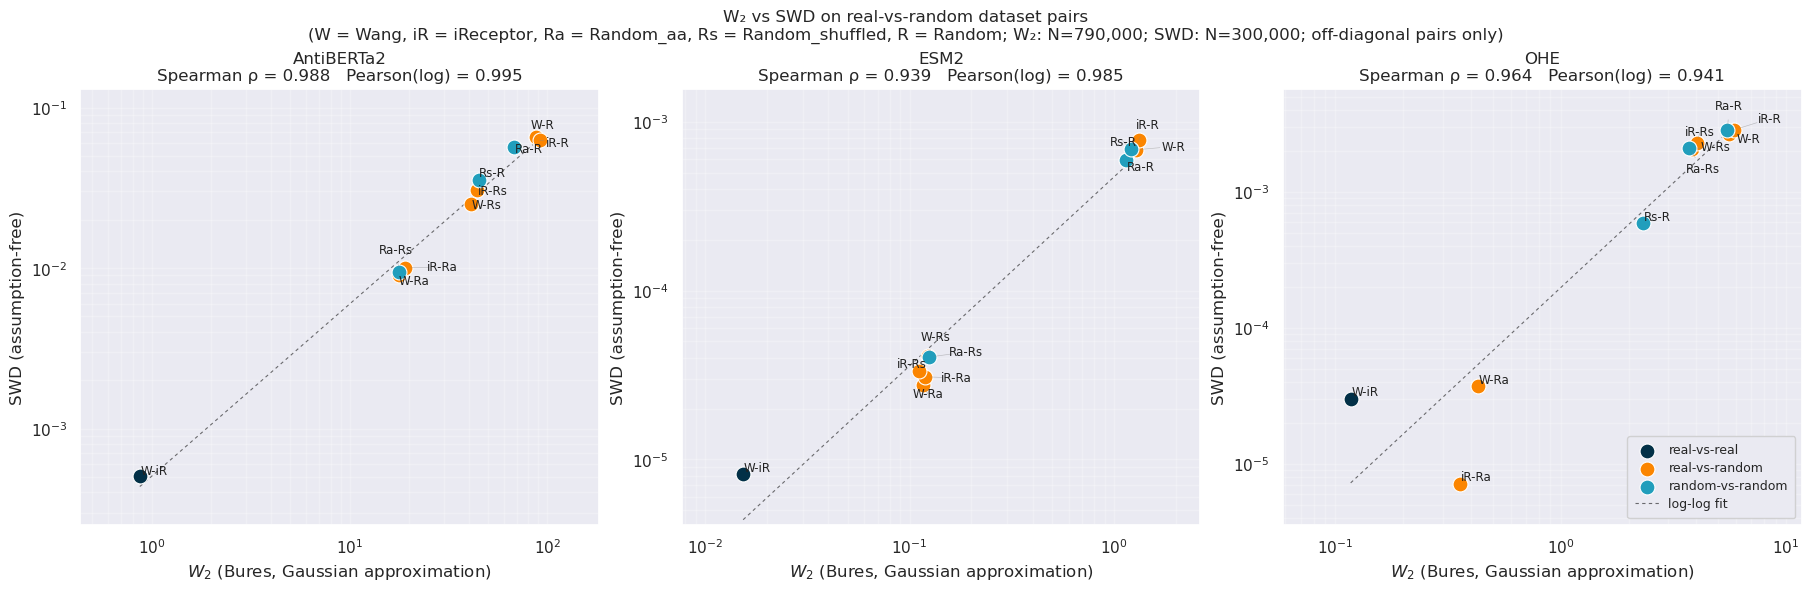

In [4]:
from scipy.stats import spearmanr, pearsonr
from adjustText import adjust_text

import numpy as np
import matplotlib.pyplot as plt
import torch

# --- Per-encoder pairwise distance vectors ---
# Both notebooks save flattened upper-triangular distance lists in the same
# order (nested loop `for i in range(5): for j in range(i, 5):`), so the
# k-th entry of each file corresponds to the same dataset pair.
encoders = ['ab2', 'esm2', 'ohe']
encoder_labels = ['AntiBERTa2', 'ESM2', 'OHE']

w2  = {e: torch.load(f'./w2_{e}.pt').numpy() for e in encoders}
swd = {e: torch.load(f'swd_{e}.pt').numpy()  for e in encoders}

# --- Reconstruct pair labels in the same order ---
dataset_names = ['Wang', 'iReceptor', 'Random_aa', 'Random_shuffled', 'Random']
short_names   = ['W',    'iR',        'Ra',        'Rs',              'R']

pairs = [(dataset_names[i], dataset_names[j])
         for i in range(5) for j in range(i, 5)]

short_pairs = [f'{short_names[i]}-{short_names[j]}'
               for i in range(5) for j in range(i, 5)]

REAL = {'Wang', 'iReceptor'}


def pair_kind(a, b):
    if a == b:
        return 'self'
    if a in REAL and b in REAL:
        return 'real-vs-real'
    if (a in REAL) ^ (b in REAL):
        return 'real-vs-random'
    return 'random-vs-random'


kinds = np.array([pair_kind(a, b) for a, b in pairs])
short_pairs = np.array(short_pairs)

# Exclude self-pairs because they are ~0 and collapse on log-log axes
off_diag = kinds != 'self'

kind_colors = {
    'real-vs-real':     '#023047',
    'real-vs-random':   '#FB8500',
    'random-vs-random': '#219EBC',
}

# --- Plot: 3 panels, one per encoder ---
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.8),
    constrained_layout=True,
)

for ax, e, label in zip(axes, encoders, encoder_labels):
    w  = w2[e][off_diag]
    s  = swd[e][off_diag]
    k  = kinds[off_diag]
    sp = short_pairs[off_diag]

    # --- Scatter points ---
    for kind, color in kind_colors.items():
        sub = k == kind
        ax.scatter(
            w[sub],
            s[sub],
            c=color,
            label=kind,
            s=115,
            edgecolor='white',
            linewidth=0.8,
            zorder=3,
        )

    ax.set_xscale('log')
    ax.set_yscale('log')

    # --- Keep axes close to actual data, with padding for labels ---
    x_pad = 2.0
    y_pad = 2.0

    x_min, x_max = np.nanmin(w), np.nanmax(w)
    y_min, y_max = np.nanmin(s), np.nanmax(s)

    ax.set_xlim(x_min / x_pad, x_max * x_pad)
    ax.set_ylim(y_min / y_pad, y_max * y_pad)

    # --- Log-log regression line ---
    log_w = np.log10(w)
    log_s = np.log10(s)

    slope, intercept = np.polyfit(log_w, log_s, 1)

    x_fit = np.logspace(np.log10(x_min), np.log10(x_max), 100)
    y_fit = 10 ** (intercept + slope * np.log10(x_fit))

    ax.plot(
        x_fit,
        y_fit,
        linestyle=(0, (3, 3)),
        linewidth=0.8,
        color='black',
        alpha=0.55,
        zorder=2,
        label='log-log fit',
    )

    # --- Non-overlapping labels ---
    texts = []

    for xi, yi, name in zip(w, s, sp):
        txt = ax.text(
            xi,
            yi,
            name,
            fontsize=8.5,
            color='#222',
            zorder=4,
        )
        texts.append(txt)

    adjust_text(
        texts,
        ax=ax,
        x=w,
        y=s,
        expand_text=(1.3, 1.5),
        expand_points=(1.5, 1.7),
        force_text=(0.5, 0.8),
        force_points=(0.3, 0.5),
        force_pull=(0.03, 0.06),
        lim=1000,
        arrowprops=dict(
            arrowstyle='-',
            color='#888',
            lw=0.45,
            alpha=0.5,
            shrinkA=10,
            shrinkB=4,
        ),
    )

    # --- Correlations ---
    rho_s, _ = spearmanr(w, s)
    rho_p, _ = pearsonr(np.log(w), np.log(s))

    ax.set_xlabel(r'$W_2$ (Bures, Gaussian approximation)', fontsize=12)
    ax.set_ylabel('SWD (assumption-free)', fontsize=12)

    ax.set_title(
        f'{label}\nSpearman ρ = {rho_s:.3f}   Pearson(log) = {rho_p:.3f}',
        fontsize=12,
    )

    ax.grid(alpha=0.25, which='both')

# --- Legend inside the last subplot, lower right corner ---
handles, legend_labels = axes[-1].get_legend_handles_labels()

axes[-1].legend(
    handles,
    legend_labels,
    loc='lower right',
    frameon=True,
    fontsize=9,
    handlelength=2.0,
    handletextpad=0.7,
    borderpad=0.6,
    labelspacing=0.4,
    framealpha=0.85,
)

fig.suptitle(
    'W₂ vs SWD on real-vs-random dataset pairs\n'
    '(W = Wang, iR = iReceptor, Ra = Random_aa, Rs = Random_shuffled, R = Random; '
    'W₂: N=790,000; SWD: N=300,000; off-diagonal pairs only)',
    fontsize=12,
)

# --- Save safely, without cropping ---
fig.savefig(
    'w2_vs_swd_scatter.png',
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.35,
)

fig.savefig(
    'w2_vs_swd_scatter.pdf',
    bbox_inches='tight',
    pad_inches=0.35,
)

plt.show()

### Rank-rank scatter

Same data, but plotting **ranks** rather than raw values. For each pair, the
x-coordinate is its rank by W₂ (1 = smallest distance, 10 = largest) and the
y-coordinate is its rank by SWD. If the two metrics rank pairs identically,
points fall exactly on the y = x diagonal. Any deviation is a rank-flip
between the two metrics.

This is the most direct visualisation of the Spearman ρ statistic and removes
the visual confounds of the log-log scatter (different scales, gaps in the
distance distribution, non-unit log-log slope).

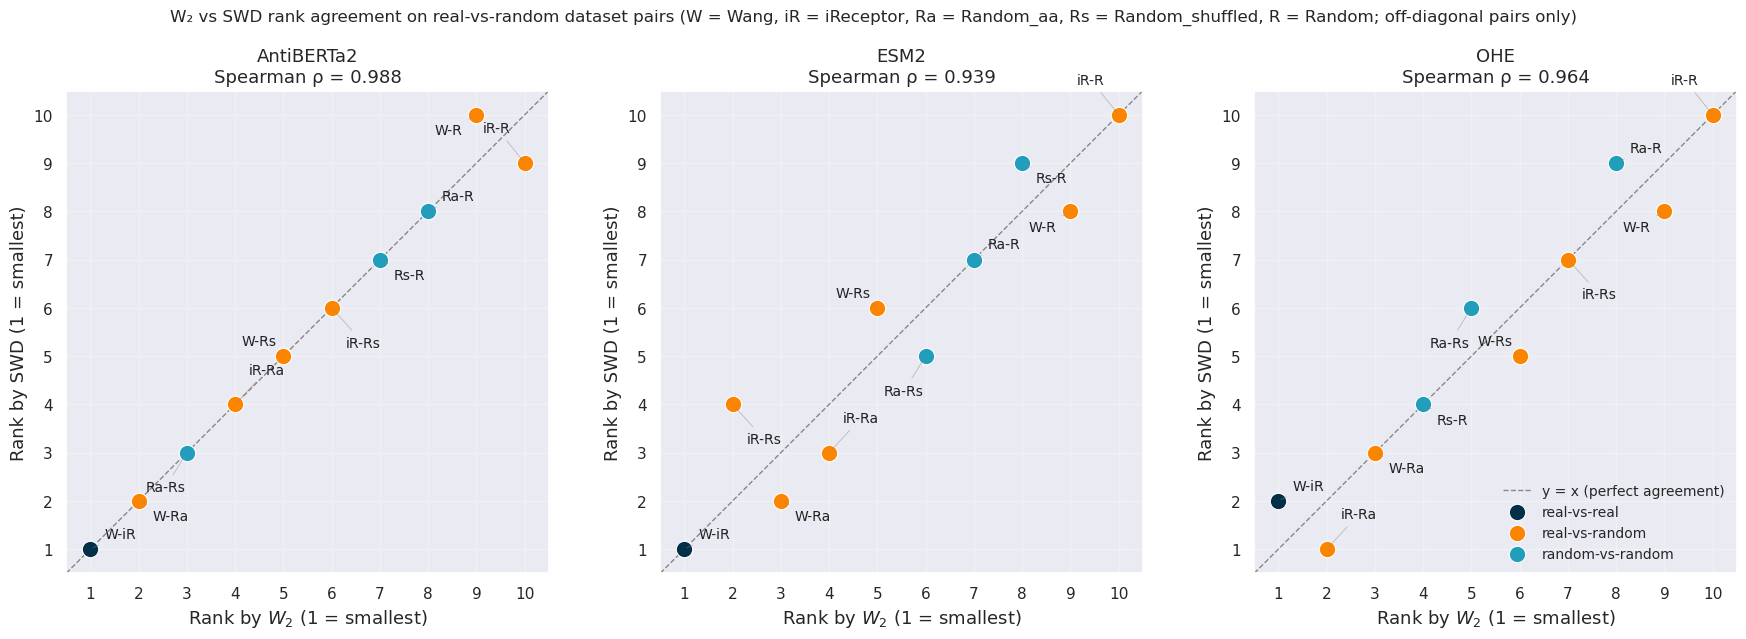

In [14]:
from scipy.stats import rankdata

# --- Plot: 3 panels (one per encoder), rank-rank scatter ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, e, label in zip(axes, encoders, encoder_labels):
    w  = w2[e][off_diag]
    s  = swd[e][off_diag]
    k  = kinds[off_diag]
    sp = short_pairs[off_diag]

    # Average ranks correctly handle ties (e.g., several SWD values that
    # round to the same number).
    w_rank = rankdata(w, method='average')
    s_rank = rankdata(s, method='average')

    n = len(w)

    # Reference y = x diagonal (perfect rank agreement).
    ax.plot([0.5, n + 0.5], [0.5, n + 0.5],
            color='#888', linestyle='--', linewidth=1, zorder=1,
            label='y = x (perfect agreement)')

    for kind, color in kind_colors.items():
        sub = k == kind
        ax.scatter(
            w_rank[sub], s_rank[sub], c=color, label=kind,
            s=140, edgecolor='white', linewidth=0.8, zorder=3,
        )

    # Annotate each point with its short pair label.
    for idx, (xi, yi, name) in enumerate(zip(w_rank, s_rank, sp)):
        dx, dy = LABEL_OFFSETS[idx % len(LABEL_OFFSETS)]
        ax.annotate(
            name,
            xy=(xi, yi),
            xytext=(dx, dy),
            textcoords='offset points',
            fontsize=10,
            color='#222',
            zorder=4,
            arrowprops=dict(arrowstyle='-', color='#888', lw=0.5, alpha=0.6),
        )

    rho_s, _ = spearmanr(w, s)

    ax.set_xlim(0.5, n + 0.5)
    ax.set_ylim(0.5, n + 0.5)
    ax.set_xticks(range(1, n + 1))
    ax.set_yticks(range(1, n + 1))
    ax.set_aspect('equal')
    ax.set_xlabel(r'Rank by $W_2$ (1 = smallest)', fontsize=13)
    ax.set_ylabel('Rank by SWD (1 = smallest)', fontsize=13)
    ax.set_title(
        f'{label}\nSpearman ρ = {rho_s:.3f}',
        fontsize=13,
    )
    ax.grid(alpha=0.3)

axes[-1].legend(loc='lower right', frameon=False, fontsize=10)

fig.suptitle(
    'W₂ vs SWD rank agreement on real-vs-random dataset pairs '
    '(W = Wang, iR = iReceptor, Ra = Random_aa, Rs = Random_shuffled, R = Random; '
    'off-diagonal pairs only)',
    fontsize=12, y=1.02,
)

plt.tight_layout()
plt.savefig('w2_vs_swd_rank_scatter.png', dpi=300)
plt.show()


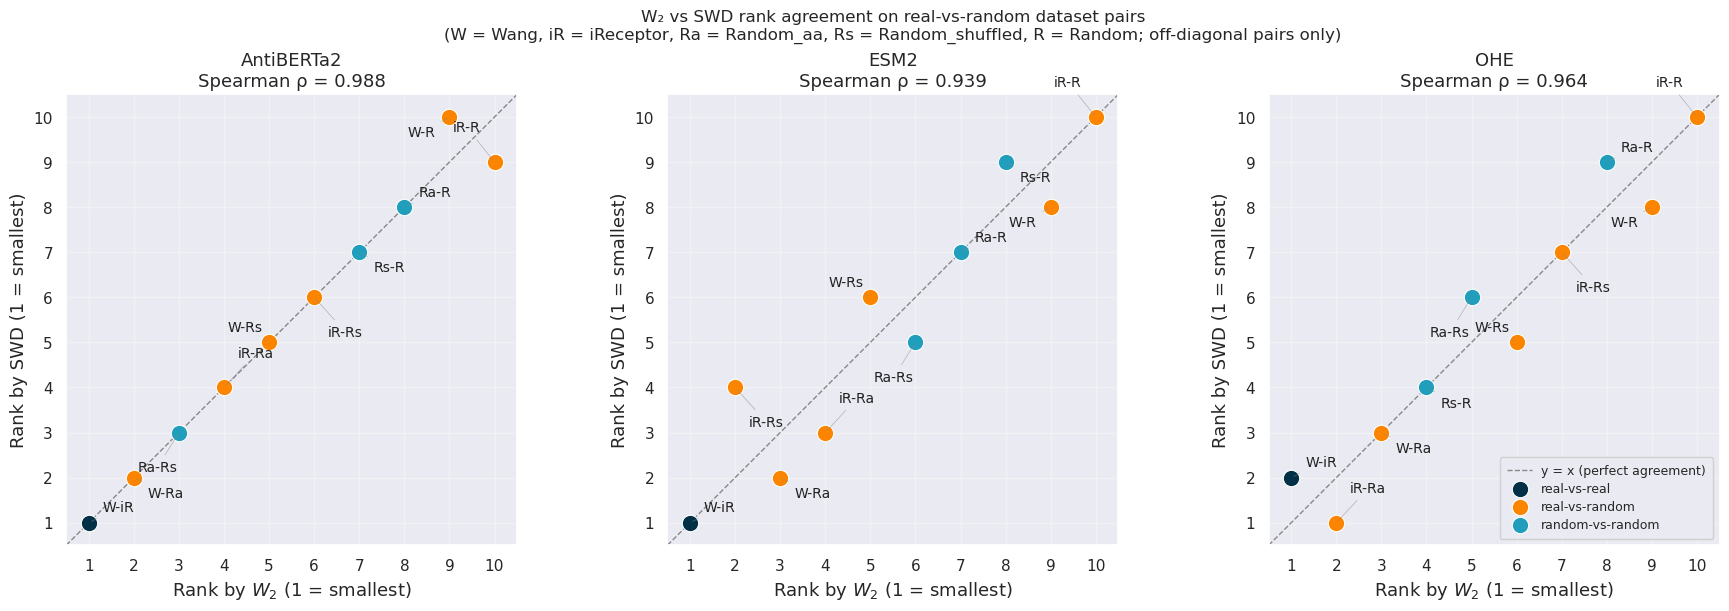

In [5]:
from scipy.stats import spearmanr, rankdata

import numpy as np
import matplotlib.pyplot as plt

# Если LABEL_OFFSETS уже определён выше, этот блок можно не дублировать.
LABEL_OFFSETS = [
    ( 10,   8),
    ( 10, -14),
    (-30,   8),
    (-30, -14),
    ( 10,  22),
    ( 10, -28),
    (-30,  22),
    (-30, -28),
]

# --- Plot: 3 panels (one per encoder), rank-rank scatter ---
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6),
    constrained_layout=True,
)

for ax, e, label in zip(axes, encoders, encoder_labels):
    w  = w2[e][off_diag]
    s  = swd[e][off_diag]
    k  = kinds[off_diag]
    sp = short_pairs[off_diag]

    # Average ranks correctly handle ties
    w_rank = rankdata(w, method='average')
    s_rank = rankdata(s, method='average')

    n = len(w)

    # Reference y = x diagonal (perfect rank agreement)
    ax.plot(
        [0.5, n + 0.5],
        [0.5, n + 0.5],
        color='#888',
        linestyle='--',
        linewidth=1.0,
        zorder=1,
        label='y = x (perfect agreement)',
    )

    # Scatter points
    for kind, color in kind_colors.items():
        sub = k == kind
        ax.scatter(
            w_rank[sub],
            s_rank[sub],
            c=color,
            label=kind,
            s=140,
            edgecolor='white',
            linewidth=0.8,
            zorder=3,
        )

    # Point labels
    for idx, (xi, yi, name) in enumerate(zip(w_rank, s_rank, sp)):
        dx, dy = LABEL_OFFSETS[idx % len(LABEL_OFFSETS)]
        ax.annotate(
            name,
            xy=(xi, yi),
            xytext=(dx, dy),
            textcoords='offset points',
            fontsize=10,
            color='#222',
            zorder=4,
            arrowprops=dict(
                arrowstyle='-',
                color='#888',
                lw=0.5,
                alpha=0.6,
            ),
        )

    rho_s, _ = spearmanr(w, s)

    ax.set_xlim(0.5, n + 0.5)
    ax.set_ylim(0.5, n + 0.5)
    ax.set_xticks(range(1, n + 1))
    ax.set_yticks(range(1, n + 1))
    ax.set_aspect('equal')

    ax.set_xlabel(r'Rank by $W_2$ (1 = smallest)', fontsize=13)
    ax.set_ylabel('Rank by SWD (1 = smallest)', fontsize=13)
    ax.set_title(
        f'{label}\nSpearman ρ = {rho_s:.3f}',
        fontsize=13,
    )
    ax.grid(alpha=0.3)

# Legend inside the last subplot
handles, legend_labels = axes[-1].get_legend_handles_labels()
axes[-1].legend(
    handles,
    legend_labels,
    loc='lower right',
    frameon=True,
    fontsize=9,
    handlelength=2.0,
    handletextpad=0.7,
    borderpad=0.6,
    labelspacing=0.4,
    framealpha=0.85,
)

fig.suptitle(
    'W₂ vs SWD rank agreement on real-vs-random dataset pairs\n'
    '(W = Wang, iR = iReceptor, Ra = Random_aa, Rs = Random_shuffled, R = Random; '
    'off-diagonal pairs only)',
    fontsize=12,
)

# Save without cropping
fig.savefig(
    'w2_vs_swd_rank_scatter.png',
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.35,
)

fig.savefig(
    'w2_vs_swd_rank_scatter.pdf',
    bbox_inches='tight',
    pad_inches=0.35,
)

plt.show()